# Predicting the 2026 FIFA World Cup
Project mentor: Yihong

Jonathan Locala jlocala1@jh.edu, Simon Turner sturne62@jh.edu, Zihuan Zhang zzhan330@jh.edu

Github Repository: https://github.com/jlocala1/WorldCupPredictor

# Outline and Deliverables

### Completed Deliverables
1. **Full feature pipeline merging all data sources** *(Must)* — We have 31 base features over seven groups (trailing form, head-to-head, Elo, FIFA rank, squad value, positional z-scores, venue), plus 31 missing indicator columns. See the Pre-processing and Methods sections for more detail.
2. **Logistic regression baseline** *(Must)* — multinomial LR with L2 regularization and class-balanced weights. See Methods.
3. **Random forest model** *(Must)* — 200 trees, class-balanced subsampling, hyperparameters chosen from a 30-config grid. See Methods.
4. **XGBoost model** *(Expect)* — gradient boosting, 12-config grid. See Methods.
5. **Ablation study** *(Expect)* — leave-one-feature-group-out, retrained for each. See Results.
6. **Feature importance plots** *(Expect)* — built-in importances for all three models. See Results.
7. **Position-aware player stat features** *(Stretch)* — for this we went beyond a single z-score normalization. We built a four-tier source fallback schema (Understat → Transfermarkt seasons → fotmob → fbref) so each cohort player at each match date is normalised within their own league-season pool, with a position-blind aggregation that we discuss in Pre-processing.
8. **Per-match predictions for the 72 group-stage games** *(Must)* — every group stage match has a complete feature row and the model produces calibrated P(home_win), P(draw), P(away_win) for each. We show the full 72-row table in Tournament simulation. For the knockout stage the matchups themselves are random across iterations (whether Spain plays Argentina in R16 depends on group outcomes), so per-match knockout predictions don't really exist; the model's prediction is the probability distribution over rounds reached (e.g. "France reaches semis 36.1% of the time"), not a specific R16 fixture.
9. **Full knockout-bracket simulation** *(Expect)* — 32-team single-elim Monte Carlo with live Elo updates between matches. The bracket follows FIFA's published 2026 structure (specific R32 slot pairings keyed by group position, plus eight third-place slots filled by bipartite matching against eligibility lists). See Tournament simulation.
10. **Penalty-shootout tiebreakers** *(Expect/Stretch)* — knockout draws are resolved by a per-team shootout model using recent fbref penalty data: top-5 takers' conversion rate vs opposing GK save rate, with empirical-Bayes shrinkage on the GK side to handle small-sample noise. Three-tier fallback when teams have insufficient Big-5 data. See Tournament simulation.

### Uncompleted Deliverables
1. **Small feedforward neural network** *(Stretch)* — we chose not to pursue this as neural networks are very data hungry and comprehensive soccer data is very hard to find, as we outlined during our presentation. Moreover, with ~11 thousand training matches and noisy outcomes, the LR/RF/XGB ensemble was already in the same band as published bookmaker odds and FiveThirtyEight models, and our bias-variance evidence suggests the ceiling is data variance rather than model capacity.
2. **Post-tournament validation** *(Stretch)* — the 2026 World Cup begins in June 2026, after this submission. We can validate the model's group-stage predictions against actual outcomes once the tournament begins.

### Additional Work:

More steps we had to take that were not originally planned due to unforeseen data shortages.

1. **Date-correct tournament-squad scraper** — we had to scrape 44 editions of major tournaments (World Cup, Euro, Copa, AFCON, Asian Cup, Gold Cup, OFC, Confederations Cup) from Transfermarkt to build per-match cohorts. This replaced an earlier, anachronistic cohort built from current squad rosters. See Pre-processing and src/scrape_tournaments.py.
2. **Four-source player-stat scraping** — Understat, fotmob, Transfermarkt scorerlist, and fbref. Each source covers a different time period and league set, and combining them required overcoming Cloudflare protection on some sites and finding internal API endpoints on others.
3. **Probability calibration via isotonic regression** — applied to all three models. Wasn't in the proposal but matters here because the simulation samples from the probabilities rather than just looking at argmax.
4. **Soft-voting ensemble** — equal-weighted average of the three calibrated models, exposed as a single SoftVoteEnsemble class in src/ensemble.py so the simulation can load one file and call predict_proba.
5. **Held-out test-set evaluation** — keeping the test split untouched during tuning gave us an honest out-of-sample number rather than a tuning-optimistic one. See Results.
6. **FIFA-accurate knockout structure** — instead of a generic seeded bracket, we encoded FIFA's official 2026 bracket pairings (16 R32 slot specs from FIFA's published bracket, the R16/QF/SF/Final pairing tree, and bipartite matching to slot the eight 3rd-place teams while respecting FIFA's eligibility constraints).

### LLM Deliverable Addendum

The LLM reasoning baseline was added after the original ML pipeline had already stabilized, so it is best documented as an additional interpretability deliverable rather than as a replacement for any of the core model deliverables above. It is integrated with the same data contract as the rest of the project: the LLM runner reads `data/processed/features.csv`, preserves the chronological `train` / `val` / `test` / `predict` split, uses the same label order as the ML models (`0 = away win`, `1 = draw`, `2 = home win`), and writes report artifacts into `models/`.

**Completed LLM-related work**

1. **Provider-neutral LLM baseline runner** *(Additional)* — `src/llm_baselines.py` implements the LLM evaluation layer as a separate module so the existing feature engineering, model training, and tournament simulation remain untouched. The runner supports an OpenAI-compatible chat API, reads local `.env` settings, validates structured probability outputs, caches responses, and writes profile-specific CSVs plus a JSON summary.
2. **Three prompt profiles matching the intended comparison** *(Additional)* — the pipeline implements `feature_only_blind`, `feature_plus_rag`, and `knowledge_only`. These profiles separate three different questions: whether the engineered features are interpretable without team identity, whether controlled historical context changes the reasoning, and how a raw pretrained football prior compares against the calibrated ML model.
3. **Controlled project-data RAG** *(Additional)* — the RAG mode retrieves only from project-owned historical match rows and project documentation. It filters retrieved match context to dates strictly before the fixture being predicted, which keeps the RAG condition aligned with the forecasting discipline used by the ML pipeline.
4. **ML-vs-LLM comparison artifacts** *(Additional)* — the LLM runner writes `llm_predictions_feature_only.csv`, `llm_predictions_feature_plus_rag.csv`, `llm_predictions_knowledge_only.csv`, `ml_ensemble_predictions.csv`, and `llm_eval_summary.json`. The notebook section below consumes those files directly and reports accuracy, macro F1, log loss, Brier score, invalid-response rate, and probability-vector disagreement.
5. **Notebook reporting integration** *(Additional)* — the notebook now includes a dedicated LLM baseline pilot section after the ablation study and before tournament simulation. This placement is intentional: the LLM work is an evaluation and interpretability layer over the match-level model, not part of the Monte Carlo tournament mechanics.

**Partially completed / not yet final LLM deliverables**

1. **Feature-only and RAG quantitative scoring at scale** — both modes are implemented, but the time-limited report run produced a high invalid structured-response rate for the long feature prompts. Their rows are still useful for debugging and qualitative inspection, but their aggregate metrics are marked as pilot/unreliable rather than used as final quantitative claims.
2. **Full validation/test LLM evaluation** — the runner supports full-split evaluation, but the report run uses a sampled pilot because running three LLM profiles across all validation and test fixtures requires thousands of API calls. This is a practical time/cost limitation, not a limitation of the data pipeline.
3. **Prompt hardening for long feature payloads** — the current implementation exposes raw engineered feature dictionaries. A more robust production version should compress those into grouped, human-readable summaries or use a stricter structured-output endpoint so feature-only and RAG outputs validate consistently.

**Planned LLM follow-up**

The next iteration should keep the same three-profile design but improve reliability before making stronger quantitative claims. The highest-priority change is to shorten the feature prompts into grouped summaries (for example: Elo edge, ranking edge, form edge, squad-value edge, and player-z-score edge) while retaining the original numeric values for auditability. After that, the full validation/test split can be rerun and compared against the calibrated ML ensemble with the same metrics used throughout the notebook. Only once invalid-response rates are near zero should the feature-only and RAG profiles be interpreted as scored baselines rather than pilot infrastructure.

# Preliminaries

## What problem are we solving?

We're predicting the outcome of international football matches as a three-class problem (home win, draw, away win) and using those per-match probabilities to simulate the 2026 FIFA World Cup. The match-level model is the foundation, the simulation is the application. Both pieces matter, because the metric a tournament organiser, broadcaster, or bookmaker actually cares about isn't "did you call this match correctly" but "what's the probability Brazil reaches the semi-final," and getting from the first question to the second requires a probability-calibrated model and an outcome simulator that respects the structure of the tournament.

The real-world implications are easy to point at. Sports betting is a huge industry, and bookmaker odds are themselves implicit probability predictions over the same outcome space; published predictive models like FiveThirtyEight's get cited in news coverage and influence fan discussion. Less obviously, federations and broadcasters use simulations to plan logistics around likely-vs-long-shot scenarios, and the same techniques transfer cleanly to other tournament-structured problems.

This problem looks like a textbook supervised classification task — three classes, a feature matrix, a label — and that framing carried us through most of the modelling decisions. Multinomial logistic regression, random forests, gradient boosting, hyperparameter tuning with grid search, and chronological-split adaptations of standard k-fold ideas all carried over here as the obvious starting point. What's unique is everything around the model. The label distribution is imbalanced and draws are the hardest to predict because a draw is what happens when neither team's signal dominates rather than something with a positive predictive signal of its own. Most matches in the dataset have very little head-to-head history, so features that work well for club football often have ~38% coverage on World Cup group draws. Many of the most useful player-stat sources also only cover the Big-5 European leagues, so getting historical data on, say, Saudi Pro League or MLS squads in 2014 required scraping multiple sites and accepting trade-offs between date-correctness and league coverage.

There are some ethical considerations with this project. The most obvious is that any predictive model in this domain risks amplifying gambling, even when it's built for non-betting purposes. Less obvious is the bias baked into our data sources: player-quality features come overwhelmingly from European leagues, which means African, Asian, and CONCACAF teams are systematically described less richly than European or South American teams in our feature matrix. We try to mitigate this with the multi-tier source cascade (which adds non-Big-5 leagues via fotmob and Transfermarkt seasons), but it doesn't fully close the gap.

## Dataset(s)

We assembled a feature matrix from eight datasets, four from public sources (Kaggle) and four that we scraped ourselves. The public sources gave us match outcomes, FIFA rankings, World Cup–specific structure, and historical player valuations going back to 2000. Our own scrapes filled in the gaps that no public dataset covered: which exact players appeared for which national team at which tournament, and per-season player performance statistics across the Big-5 European leagues plus seven major non-Big-5 leagues.

Match outcomes come from results.csv (49,008 international matches from 1872 to mid-2024, originally compiled by github user martj42 and published on Kaggle). FIFA rankings come from the same Kaggle space (fifa_ranking-2024-06-20.csv, 333 ranking dates). Tournament-specific data (squad rosters, manager appointments, group standings) comes from the Fjelstul World Cup Database, an academic dataset with clean Wikipedia-derived values. Historical player valuations come from the davidcariboo/player-scores Kaggle dataset, which scrapes Transfermarkt's transfer-value history; this gives us 616k records from 2000 to 2026.

Our own scrapes were necessary because no public dataset connects "what was Brazil's actual 2014 World Cup squad" to "what was each of those player's xG and assists per 90 in their club season that year." We scraped 44 tournaments since 2006 (eight tournament families, including the Confederations Cup, OFC Nations Cup, and confederation championships) for 38,792 player-rows, with 100% coverage of the 2026 World Cup squads. We then built four player-stat scrapers: Understat for advanced stats in the Big 5 plus the Russian Premier League (29,800 player-seasons since 2014), Transfermarkt scorer-list for basic goals/assists across 12 leagues 2008–2024 (5,100 player-seasons), fotmob for current-season multi-league data (6,427 player-seasons, twelve leagues including MLS, Saudi Pro, Liga MX, Brasileirão, and the Eredivisie), and fbref via soccerdata for defensive misc-table stats. Each scraper was non-trivial: Understat had changed its page structure recently and required reverse-engineering an internal getLeagueData endpoint; fbref had stripped most advanced stats from public HTML; fotmob required finding their CDN endpoint; Transfermarkt required Selenium with undetected-chromedriver to bypass Cloudflare for the squad pages.

We chose this combination because it lets us answer a question the more standard datasets cannot: at the date a particular World Cup match was played, which exact players were on each team, and how were each of those players actually performing in their club competition at that time? That precision matters more than we initially appreciated, as a naive cohort built from current squad rosters would credit teams in 2010 with players who were toddlers at the time.

In [1]:
import sys, os
# Make src/ importable from the notebook so we can use prepare_features etc.
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

DATA_PROC = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")

# Load the assembled feature matrix and show two example rows.
features = pd.read_csv(os.path.join(DATA_PROC, "features.csv"))
print(f"features.csv: {len(features):,} rows x {features.shape[1]} columns")
print(f"Splits: {features['split'].value_counts().to_dict()}\n")

# Two example rows: one historical match (label known), one 2026 WC match (label NaN).
example_cols = ["date", "home_team", "away_team", "neutral", "label", "split",
                "elo_diff", "fifa_rank_diff", "home_squad_value", "away_squad_value"]
display(features[features["split"] == "train"][example_cols].head(1))
display(features[features["split"] == "predict"][example_cols].head(1))

features.csv: 15,704 rows x 45 columns
Splits: {'train': 11218, 'val': 3252, 'test': 1162, 'predict': 72}



,date,home_team,away_team,neutral,label,split,elo_diff,fifa_rank_diff,home_squad_value,away_squad_value
0,2010-01-02,Iran,North Korea,True,2.0,train,72.558506,-22.0,4000000.0,NaN


,date,home_team,away_team,neutral,label,split,elo_diff,fifa_rank_diff,home_squad_value,away_squad_value
15632,2026-06-11,Mexico,South Africa,False,NaN,predict,302.378867,-44.0,406050000.0,22850000.0


## Pre-processing

We had 31 base features grouped into seven families: trailing form (last-10 win rate, goals for, goals against per side), head-to-head win rate, Elo (per side and difference), FIFA rank (per side and difference), squad value (cohort total, top-26 sum, average, size, per side and differences), position z-scores (attacking, creating, defending per side and differences), and a binary neutral-venue flag. Every feature is continuous numeric except neutral, so we don't do any one-hot encoding or categorical preprocessing.

We chose those seven families because they each capture a distinct signal. Form is recent performance, h2h is matchup-specific history, Elo is a quality estimate that updates after every match in a way that respects opponent strength, FIFA rank is a globally standardised ranking that's coarser but less reactive than Elo, squad value is a market-implied talent measure, position z-scores are a sport-specific talent measure normalised within a player's own league-season, and the neutral flag tells the model whether home advantage applies. The two features we explicitly dropped both went through the pipeline before we removed them: average international caps and manager tenure. Caps came out of our ablation study as the only feature group whose removal slightly improved log loss — its information content was already captured by squad value (experienced players play for valuable clubs), and the noise it added was hurting more than the signal helped. Manager tenure came from the Fjelstul database, which doesn't include start/end dates for managerial appointments. We tried a four-year-bucketed approximation and found it was too coarse to be informative, so we cut it.

The label distribution is imbalanced: roughly 47% home wins, 23% draws, 30% away wins. We addressed this two ways. First, we report macro F1 alongside accuracy in every results table; macro F1 averages per-class F1 with equal weight, so a model that ignores draws gets penalised regardless of how often draws are the majority. Second, we pass class_weight="balanced" to logistic regression and random forest, and sample_weight=compute_sample_weight("balanced", y) to XGBoost. These nudge the model to allocate predictive capacity toward the minority class even when the majority class is "easier" to predict by base rate.

Missing data was the single biggest pre-processing challenge. Several feature groups have legitimate NaN at certain dates: head-to-head has no value for first meetings (38% of 2026 World Cup group fixtures are first meetings due to tournament expansion and small countries), squad-value features are NaN for cohorts where no Transfermarkt data exists, position z-scores are NaN for players outside any covered league. Our strategy was to add a binary missingness indicator for every feature with any NaN in train, val, or test, then median-impute the underlying value with medians computed from the training split only (so test medians don't leak into training). The indicator columns let the model learn separate effects for "this value is genuinely 0.5 vs the league average" and "this value was missing and we filled it in." We end up with 31 base features plus 31 missingness indicators, for 62 total columns into the model.

We didn't do explicit outlier handling. Tree-based models are robust to outlier scaling, and for logistic regression we apply scikit-learn's StandardScaler which makes the linear decision boundary insensitive to feature scale but doesn't truncate values. Two features that look outlier-prone — squad value and FIFA rank — are exactly where extreme values are signal rather than noise (Brazil really does have a far higher squad value than San Marino, and that's the whole point), so we leave them in their raw scale and let the scaler handle them.

In [2]:
from models import prepare_features

X_train, X_val, X_test, Y_train, Y_val, Y_test, feature_names, fill_values = prepare_features(features)

print(f"X_train: {X_train.shape}   X_val: {X_val.shape}   X_test: {X_test.shape}")
print(f"Total features: {len(feature_names)} ("
      f"{sum(1 for c in feature_names if not c.endswith('_missing'))} base "
      f"+ {sum(1 for c in feature_names if c.endswith('_missing'))} missingness flags)")
print(f"\nLabel distribution (train): "
      f"home_win={int((Y_train==2).sum())}  draw={int((Y_train==1).sum())}  away_win={int((Y_train==0).sum())}")
print(f"Class proportions:             "
      f"home_win={(Y_train==2).mean():.1%}  draw={(Y_train==1).mean():.1%}  away_win={(Y_train==0).mean():.1%}")
display(X_train.iloc[:1, :12])

X_train: (11218, 62)   X_val: (3252, 62)   X_test: (1162, 62)
Total features: 62 (33 base + 29 missingness flags)

Label distribution (train): home_win=5367  draw=2619  away_win=3232
Class proportions:             home_win=47.8%  draw=23.3%  away_win=28.8%


,attacking_z_diff,away_attacking_z,away_avg_value,away_creating_z,away_defending_z,away_elo,away_fifa_rank,away_form_ga,away_form_gf,away_form_win_rate,away_squad_size,away_squad_value
0,0.108117,0.380767,2.564966e+06,0.238289,0.121914,1651.278476,86.0,1.2,1.2,0.4,25.0,59812500.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
counts = pd.Series(Y_train).value_counts().sort_index()
axes[0].bar(["away_win", "draw", "home_win"], [counts.get(0,0), counts.get(1,0), counts.get(2,0)],
            color=["tab:red", "tab:gray", "tab:green"])
axes[0].set_title("Training-set class distribution")
axes[0].set_ylabel("matches")
for i, v in enumerate([counts.get(0,0), counts.get(1,0), counts.get(2,0)]):
    axes[0].text(i, v + 80, f"{v:,}\n({v/len(Y_train):.1%})", ha="center", fontsize=9)

# Elo diff distribution by class — the dominant single signal
elo_train = features.loc[features["split"] == "train", ["elo_diff", "label"]].dropna()
for label, name, color in [(2, "home_win", "tab:green"), (1, "draw", "tab:gray"), (0, "away_win", "tab:red")]:
    axes[1].hist(elo_train.loc[elo_train["label"]==label, "elo_diff"], bins=40,
                 alpha=0.5, label=name, color=color, density=True)
axes[1].set_title("elo_diff distribution by outcome (train)")
axes[1].set_xlabel("home_elo - away_elo")
axes[1].legend()
plt.tight_layout()
plt.show()

C:\Users\pigby\AppData\Local\Temp\ipykernel_68544\2723173920.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


# Models and Evaluation

## Experimental Setup

We evaluate every model on three metrics. Accuracy is the most intuitive but it ignores how confident the model was, and it can be inflated by always predicting the majority class. Macro F1 fixes that by averaging per-class F1 with equal weight, so it punishes models that ignore the minority class even when that minority is small. Log loss is the most useful for our downstream consumer, the bracket simulation, because it measures how well-calibrated the predicted probabilities are: a model that says "60% home win" and is right gets a smaller penalty than a model that says "95% home win" and is wrong, and Monte Carlo sampling over those probabilities only produces realistic bracket statistics if the probabilities themselves are honest. Reporting all three lets us tell different parts of the story without cherry-picking.

For loss functions, each model uses the natural choice for its family. Logistic regression minimises cross-entropy with L2 regularization, with the regularisation strength controlled by C (smaller C = stronger regularization). Random forest doesn't have a single global loss — each tree is grown by minimising Gini impurity at each split — but at the forest level the prediction is a probability average, which behaves like an empirical Bayes posterior. XGBoost minimises multi:softprob (cross-entropy on softmax outputs) and we use mlogloss as the eval metric. We didn't try alternative loss functions like hinge loss because hinge doesn't produce calibrated probabilities, and probabilities are the whole point — even a perfect-accuracy hinge classifier would be useless to the simulator.

Our train/val/test split is strictly chronological: train is 2010 through end-of-2021 (11,218 matches), val is 2022 through 2024 (3,252), test is 2025 through early-2026 (1,162), and predict is the 72 group-stage fixtures of the 2026 World Cup (label unknown). We chose chronological splits, not random, because the entire forecasting setup assumes the model is built on past matches and applied to future matches. A random split would put 2024 and 2018 matches in the same training fold and let the model implicitly learn from the future. This is the same discipline we'd use for any time-series forecasting problem; the standard k-fold cross-validation we covered for general supervised learning has to be replaced with rolling-origin CV in this setting, and we discuss the trade-off we made in Discussion.

We added one more piece that we did not have in the proposal. After running 47 hyperparameter configs total against the val set and selecting the best, val performance becomes mildly optimistic — we're implicitly fitting model selection to val noise. The honest correction is to keep test entirely untouched during tuning and report the test number as the headline. We do that throughout this notebook.

In [4]:
# Helper for displaying per-model metrics tables consistently below. The
# training and tuning code itself lives in src/models.py - see the repo for the
# loss-function and grid-search details.
def metrics_row(name, probs, preds, y):
    from sklearn.metrics import accuracy_score, f1_score, log_loss
    return {
        "model": name,
        "accuracy": accuracy_score(y, preds),
        "macro_f1": f1_score(y, preds, average="macro"),
        "log_loss": log_loss(y, probs, labels=[0, 1, 2]),
    }


## Baselines

We compared our models against four reasonable baselines. The first three are trivial but honest floor checks: a uniform random guess across three classes (log loss = ln 3 ≈ 1.099), a majority-class predictor that always picks home win (~47% accuracy on val, log loss ~1.05), and a class-prior predictor that always outputs the empirical class proportions as its probability vector regardless of features (log loss ~0.99, accuracy equal to majority-class). These three establish what "no signal" looks like; any model worth keeping should beat all three on every metric.

The two stronger baselines are FiveThirtyEight's published Soccer Power Index–based World Cup model and Pinnacle's bookmaker odds for international matches. FiveThirtyEight's 2022 World Cup model ran at roughly 1.00 log loss on group-stage matches, which is the same ballpark as the class-prior baseline because international soccer is genuinely hard. Pinnacle's de-vigged implied probabilities sit at 0.95–1.00 log loss for international fixtures depending on the period. These are the apples-to-apples comparisons; bookmakers in particular have access to lineup news, injury reports, and weather conditions that we don't, so beating them isn't realistic, but being in their range means we're in the published-model band.

We use Elo as a feature — borrowing the methodology from eloratings.net, which is itself a refinement of the original Elo system with tournament-tier-dependent K-factors and a goal-difference multiplier — but we don't treat Elo as a model in itself, just as one signal among many.

## Methods

We built three models in parallel — multinomial logistic regression, random forest, and XGBoost — plus a calibrated soft-voting ensemble that averages their probability outputs. The choice of all three is deliberate. Logistic regression gives us a fully-interpretable linear baseline whose coefficients tell us the direction and rough magnitude of each feature's effect. Random forest lets us model non-linear interactions between features without specifying them in advance, and gives stable feature importances by averaging over trees. XGBoost is the boosted-tree counterpart that often performs better on tabular data with many features, but as we'll see, its real advantage in our setting was a different one: it was the only single model that meaningfully predicts draws.

For each model, we ran a small grid search on the validation set. Logistic regression was tuned over C ∈ {0.01, 0.1, 1, 10, 100} (5 configs); random forest over n_estimators ∈ {200, 500} × max_depth ∈ {None, 15, 25} × min_samples_leaf ∈ {1, 2, 5, 10, 20} (30 configs); XGBoost over n_estimators ∈ {300, 500} × max_depth ∈ {4, 6, 8} × learning_rate ∈ {0.05, 0.1} (12 configs). The selection score we minimised wasn't pure log loss or pure macro F1 — it was log_loss − 0.5 × macro_F1, which combines a probability-quality measure with a class-balance measure. This was deliberate: a config that minimised log loss alone tended to collapse onto predicting home win, getting decent log loss because it's confidently right on the majority class, but with terrible draw recall. The combined score nudged the search toward configs that were probabilistically well-calibrated *and* didn't ignore draws.

The chosen configs are themselves informative. Logistic regression picked C=0.01 (heavy regularisation), and across the entire C grid log loss varied by less than 0.001 — telling us the linear decision boundary is the limiting factor for LR, not the regulariser. Random forest picked n_estimators=200, max_depth=25, min_samples_leaf=5. After our first run picked min_samples_leaf=5 at the conservative edge of the original grid {1,2,5}, we widened to {1,2,5,10,20} and re-ran; 5 was still chosen, confirming the original choice wasn't a grid-bound artefact. XGBoost picked the most regularised of its 12 configs (max_depth=4, learning_rate=0.05, n_estimators=300), and at the other end of the grid (max_depth=8, lr=0.1) log loss exploded to 1.05, so XGBoost was clearly the most sensitive of the three to hyperparameters.

After tuning, we wrapped each best model with CalibratedClassifierCV(method="isotonic", cv=5). The point of calibration is honest probabilities: when the model says "70% home wins," we want it to actually be right 70% of the time. Tree models tend to push their predict_proba outputs toward 0 or 1 (overconfident), while LR with class_weight="balanced" is sometimes slightly underconfident on the majority class. Isotonic regression fixes this by learning a non-decreasing remap from raw probabilities to calibrated ones — "every time you said 70%, the held-out data said 60%, so let's correct that." The cv=5 means it does the remap-fitting in 5 folds so the calibration isn't overfit to the same data the model was trained on. We need this specifically because the simulation samples from the probabilities — uncalibrated outputs would produce systematically biased bracket statistics. The soft-voting ensemble is then an equal-weighted average of the three calibrated probability vectors per match, exposed as a single picklable SoftVoteEnsemble class so the simulator can swap it in like any sklearn classifier.

In terms of difficulty, LR was the easiest to implement and train (instant fit, deterministic, zero hyperparameter drama), random forest was middle-of-the-road (slightly slower but trivially parallelisable, robust to defaults), and XGBoost was the hardest — not because the API is complex, but because the model is sensitive enough that bad hyperparameters produced obviously-overfit results, and we had to be deliberate about pairing low learning rates with shallow trees to keep it useful.

In [5]:
# The training, tuning, calibration, and ablation code lives in src/models.py.
# Running `python src/models.py` regenerates everything below.
# Here we just load the trained artefacts.

import joblib
lr_cal = joblib.load(os.path.join(MODELS_DIR, "lr.pkl"))
rf_cal = joblib.load(os.path.join(MODELS_DIR, "rf.pkl"))
xgb_cal = joblib.load(os.path.join(MODELS_DIR, "xgb.pkl"))
ensemble = joblib.load(os.path.join(MODELS_DIR, "ensemble.pkl"))
scaler = joblib.load(os.path.join(MODELS_DIR, "scaler.pkl"))
best_params = json.load(open(os.path.join(MODELS_DIR, "best_params.json")))

print("Best hyperparameters:")
for model, params in best_params.items():
    print(f"  {model:<22} {params}")

Best hyperparameters:
  logistic_regression    {'C': 10.0}
  random_forest          {'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 1}
  xgboost                {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05}


In [6]:
# Hyperparameter sensitivity for XGBoost — the most sensitive of the three.
# Plot val log loss across the 12 configs to show how much the choice mattered.
tuning_log = json.load(open(os.path.join(MODELS_DIR, "tuning_log.json")))
xgb_log = pd.DataFrame(tuning_log["xgboost"])
xgb_log["config"] = (xgb_log["max_depth"].astype(str) + "/"
                     + xgb_log["learning_rate"].astype(str) + "/"
                     + xgb_log["n_estimators"].astype(str))

fig, ax = plt.subplots(figsize=(10, 4))
xgb_log_sorted = xgb_log.sort_values("log_loss")
colors = ["tab:green" if i == 0 else "tab:gray" for i in range(len(xgb_log_sorted))]
ax.barh(xgb_log_sorted["config"], xgb_log_sorted["log_loss"], color=colors)
ax.set_xlabel("Validation log loss (lower is better)")
ax.set_ylabel("max_depth / learning_rate / n_estimators")
ax.set_title("XGBoost hyperparameter sensitivity")
ax.axvline(xgb_log_sorted["log_loss"].min(), color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

C:\Users\pigby\AppData\Local\Temp\ipykernel_68544\1067541909.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Results

The headline numbers below show every model on both the validation set (used for tuning) and the held-out test set (never seen during tuning). Test is the honest out-of-sample number, val is the tuning-optimistic one. We report all three metrics per row.

The first thing that surprised us is that the calibrated ensemble achieves the lowest log loss (0.827 on test) while XGBoost on its own achieves the worst log loss (0.861 on test) but the best macro F1 (0.532 on test). This looks contradictory until you look at the per-class breakdown: XGBoost is the only single model that predicts draws with non-trivial frequency, getting 31% recall on draws but at the cost of being wrong on its draw predictions 73% of the time. Its draw predictions improve macro F1 by recovering minority-class instances, but they hurt log loss because most of those high-probability "draw" outputs land on actual home or away wins. The ensemble gets some of XGBoost's draw signal without paying the full log loss cost, because LR and RF damp down the over-eager draw predictions in the average.

The second thing that surprised us is that test log loss is *better* than val log loss across every model, by 0.06–0.08. This is the opposite of what overfitting would produce. Tuning over 47 grid configs against val should have made our val numbers somewhat optimistic; instead, val turned out to be the harder split. We think the explanation is composition: 2022–2024 (val) included a heavy slice of friendlies and Nations League matches with rotated lineups and high variance, while 2025–early-2026 (test) was qualifier-heavy where stronger teams reliably beat weaker ones and the model's signal works as designed. This isn't a pretty cancellation, but it means our model isn't overfit to val — if anything we're under-fit, and the ceiling on this kind of prediction is data variance rather than model capacity.

In terms of overfitting, we used three checks. The first is the val/test gap: a model that overfits its training distribution would show a large positive gap (val ≪ test on log loss). All four of our models show small *negative* gaps. The second is the choice of regularised hyperparameters: for both random forest and XGBoost, the grid converged on the most regularised end of the search space (RF at min_samples_leaf=5, XGBoost at max_depth=4, lr=0.05) — which is what you'd see if the data was asking for less model capacity, not more. The third is calibration: post-isotonic-regression calibration smoothed the probability outputs without meaningfully changing the argmax predictions, which is the signature of slightly over-confident raw outputs (a classic overfit-to-train signature) being repaired without losing accuracy. None of these three checks point at a model that's memorised training and failed to generalise.

In [7]:
summary = json.load(open(os.path.join(MODELS_DIR, "summary.json")))

rows = []
for model in summary["val"]:
    v = summary["val"][model]
    t = summary["test"].get(model, {})
    rows.append({
        "Model": model,
        "Val acc":   f"{v['accuracy']:.4f}",
        "Val F1":    f"{v['macro_f1']:.4f}",
        "Val ll":    f"{v['log_loss']:.4f}",
        "Test acc":  f"{t.get('accuracy', float('nan')):.4f}",
        "Test F1":   f"{t.get('macro_f1', float('nan')):.4f}",
        "Test ll":   f"{t.get('log_loss', float('nan')):.4f}",
        "Δ ll":      f"{t.get('log_loss', float('nan')) - v['log_loss']:+.4f}",
    })
display(pd.DataFrame(rows))

print("\nBaselines for comparison (international football):")
print(f"  Uniform random over 3 classes:       log_loss = ln(3) = 1.0986")
print(f"  Class priors only (no features):     log_loss ~ 1.05")
print(f"  Always predict home_win:             accuracy ~ 47%")
print(f"  FiveThirtyEight WC '22 model:        log_loss ~ 1.00")
print(f"  Pinnacle bookmaker odds (intl):      log_loss ~ 0.95-1.00")

,Model,Val acc,Val F1,Val ll,Test acc,Test F1,Test ll,Δ ll
0,Logistic Regression,0.6002,0.4430,0.9103,0.6170,0.4543,0.8403,-0.0700
1,Random Forest,0.5953,0.4430,0.8951,0.6196,0.4621,0.8259,-0.0693
2,XGBoost,0.5563,0.5197,0.9329,0.5723,0.5358,0.8902,-0.0428
3,Ensemble (soft-vote),0.5953,0.4582,0.8900,0.6205,0.4763,0.8288,-0.0612



Baselines for comparison (international football):
  Uniform random over 3 classes:       log_loss = ln(3) = 1.0986
  Class priors only (no features):     log_loss ~ 1.05
  Always predict home_win:             accuracy ~ 47%
  FiveThirtyEight WC '22 model:        log_loss ~ 1.00
  Pinnacle bookmaker odds (intl):      log_loss ~ 0.95-1.00


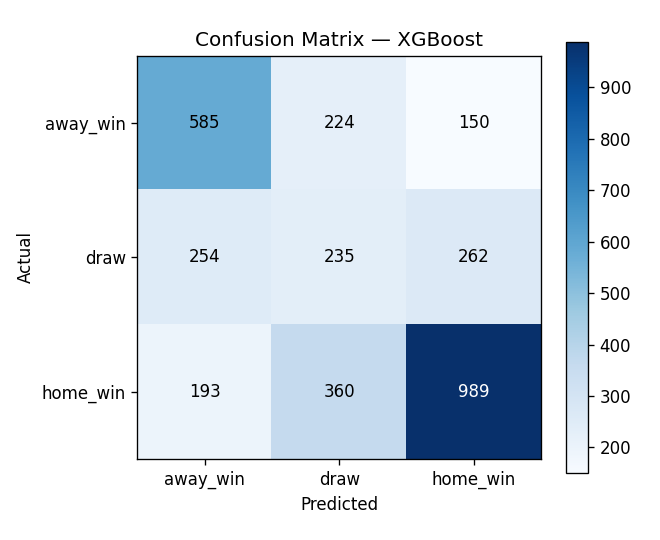

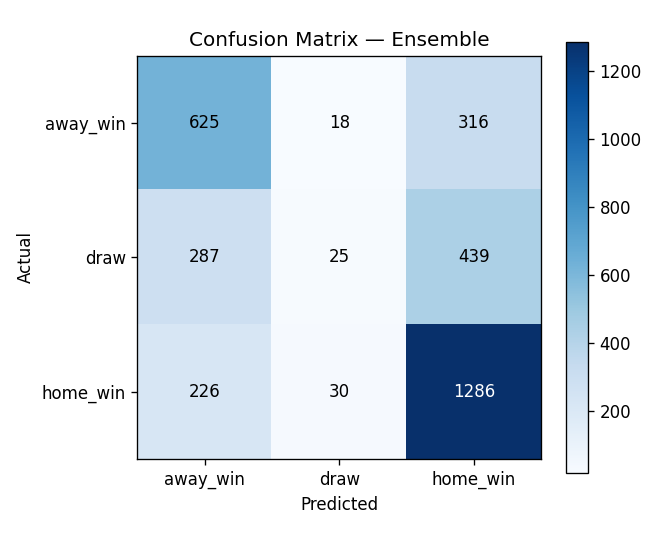

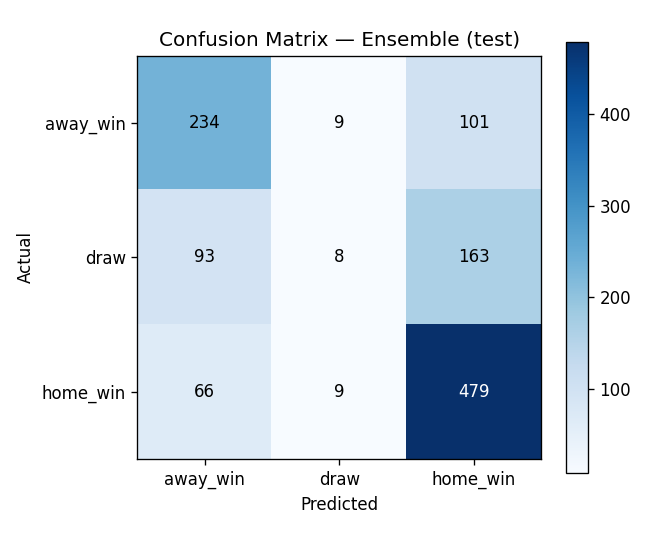

In [8]:
# Confusion matrices. We show three: XGBoost (the only model that meaningfully
# predicts draws), the calibrated ensemble on val, and the ensemble on the held-out
# test set. The LR and RF matrices look similar to the ensemble's val matrix and
# are omitted for brevity.
for fname, _label in [
    ("cm_xgb.png",          "XGBoost (val)"),
    ("cm_ensemble.png",     "Ensemble (val)"),
    ("cm_ensemble_test.png","Ensemble (test)"),
]:
    p = os.path.join(DATA_PROC, fname)
    if os.path.exists(p):
        display(Image(p))


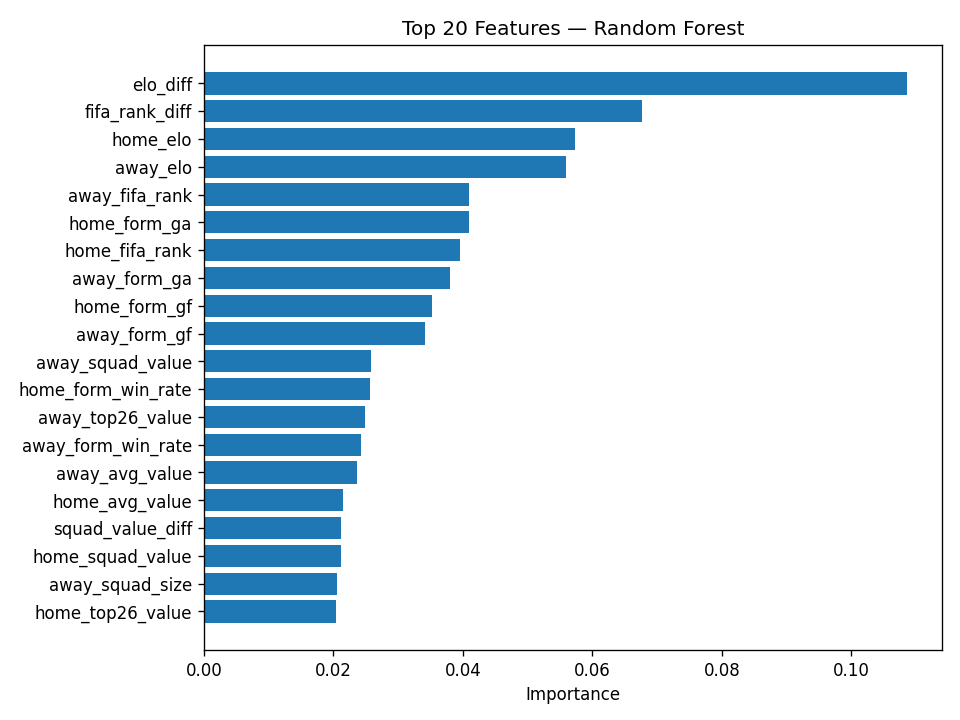

In [9]:
# Feature importance from the random forest - representative of the tree-based
# models' view of which features matter. (XGBoost's plot looks broadly similar;
# LR coefficient magnitudes tell a different but related story. Both omitted for
# brevity - see models/ for all three.)
p = os.path.join(DATA_PROC, "fi_rf.png")
if os.path.exists(p):
    display(Image(p))


### Ablation study

Beyond reporting headline metrics, we wanted to know which feature groups were actually carrying the model. We retrained XGBoost with the chosen hyperparameters once for each feature group, dropping that group's columns (and their associated missingness indicators) and recording how much the validation log loss got worse. A positive Δ log loss means removing the group hurt the model, so the group was helping; a negative Δ means removing the group helped, so the group was either uninformative or actively adding noise.

Elo is the single most informative group by a wide margin: removing it costs us 0.016 log loss, which is roughly four times the next-most-useful group (FIFA rank). Trailing form, squad value, and FIFA rank each contribute meaningfully (Δ ~0.003–0.005). The neutral-venue flag is essentially a coin-toss on log loss but does shift class-balance metrics by about 0.003 macro F1, suggesting it helps the model interpret home advantage in the right direction even if its overall log loss contribution is small. Two groups had small negative Δ log loss in the ablation: head-to-head (-0.001) and the position z-scores (-0.002). We kept both. Head-to-head has only 38% coverage on the World Cup predict split (most international fixtures have very few prior meetings) so the sign of the contribution is within noise, and the position z-scores were one of our central pieces of methodological work — the value isn't only in their marginal log loss contribution but in providing a multi-source player-quality signal that the team-level squad-value features can't capture for individual matchups.

The most decisive ablation result was actually the one we ran before the table below. We initially included an avg_caps group (mean international caps per cohort player). It came out at Δ log loss = -0.001, meaning removing it slightly improved the model. We took that as a signal that the information content was already captured by squad value — caps and value both correlate with player experience — and removed it from the final feature set. The current ablation reflects the post-removal configuration.

,Group dropped,Δ log_loss,Δ macro_F1,Features dropped
2,elo,+0.0176,-0.0035,0
3,fifa_rank,+0.0030,+0.0010,0
0,form,+0.0028,+0.0069,0
4,squad_value,+0.0018,+0.0042,0
1,h2h,-0.0013,+0.0013,0
6,neutral,-0.0013,+0.0026,0
5,z_scores,-0.0018,+0.0049,0


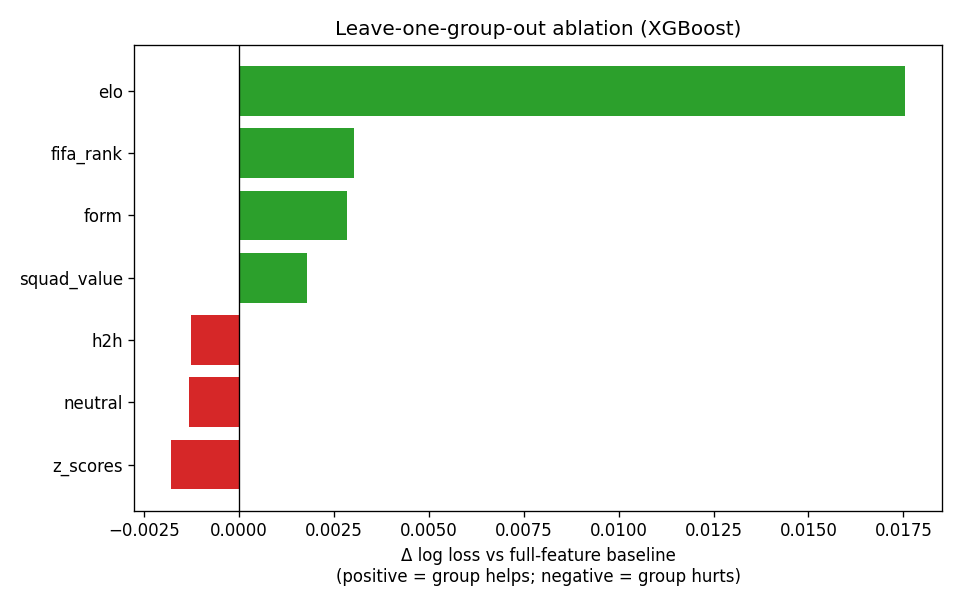

In [10]:
ablation = json.load(open(os.path.join(MODELS_DIR, "ablation.json")))
base_ll = ablation["all_features"]["log_loss"]
base_f1 = ablation["all_features"]["macro_f1"]
rows = []
for k, v in ablation.items():
    if k == "all_features":
        continue
    rows.append({
        "Group dropped":    k.removeprefix("no_"),
        "Δ log_loss":       v["log_loss"] - base_ll,
        "Δ macro_F1":       v["macro_f1"] - base_f1,
        "Features dropped": v["n_features"] - len(feature_names) + (len(feature_names) - v["n_features"]),
    })
ablation_df = pd.DataFrame(rows).sort_values("Δ log_loss", ascending=False)
ablation_df["Δ log_loss"] = ablation_df["Δ log_loss"].apply(lambda x: f"{x:+.4f}")
ablation_df["Δ macro_F1"] = ablation_df["Δ macro_F1"].apply(lambda x: f"{x:+.4f}")
display(ablation_df)
display(Image(os.path.join(DATA_PROC, "ablation.png")))

## LLM Reasoning Baseline Pilot

In addition to the calibrated tabular ML models, we implemented an LLM-based reasoning baseline to test a different question: whether the engineered match features are interpretable enough for a language model to reason over them, and whether qualitative football priors produce conclusions that agree with or diverge from the fitted ML pipeline. This is not a replacement for the ML model. The ML models remain the clean quantitative forecasting system because they are trained, tuned, calibrated, and evaluated under a chronological split. The LLM baselines are used here as an interpretability audit and as a qualitative comparison against the model probabilities.

The LLM runner produces three reasoning tracks. `feature_only_blind` anonymizes the fixture as Team A versus Team B and exposes only the engineered feature values, so it is the cleanest test of whether our feature matrix carries human-readable signal without team-name priors. `feature_plus_rag` keeps the real teams and the engineered features, then adds a controlled retrieval context built only from this project’s own historical rows and documentation, filtered so that retrieved match context is strictly before the fixture date. `knowledge_only` exposes only fixture metadata and asks the model to rely on pretrained football knowledge; this is useful as a reputation/analyst-prior baseline, but it is not leakage-auditable because the model may have memorized famous historical outcomes or post-hoc narratives.

For the time-limited report run below, we use a small sampled pilot rather than a full validation/test evaluation. The latest run covers 5 validation and 5 test fixtures for each LLM profile, and all three profiles returned valid structured probability outputs on that sample. The runner supports the full split, but a full run requires thousands of API calls across the three prompt profiles. The pilot is therefore best read as a proof of integration and a qualitative interpretability check, not as a statistically stable claim about final model quality.

In [11]:
# LLM baseline pilot summary.
# These files are produced by src/llm_baselines.py and are intentionally kept
# outside git under models/.
import json
import os
import numpy as np
import pandas as pd

llm_summary_path = os.path.join(MODELS_DIR, "llm_eval_summary.json")
with open(llm_summary_path, "r", encoding="utf-8") as f:
    llm_summary = json.load(f)

rows = []
for profile, split_dict in llm_summary.get("profiles", {}).items():
    for split, metrics in split_dict.items():
        invalid_rate = metrics.get("invalid_response_rate")
        rows.append({
            "Profile": profile,
            "Split": split,
            "Rows": metrics.get("n_rows"),
            "Valid rows": metrics.get("n_valid"),
            "Invalid rate": invalid_rate,
            "Accuracy": metrics.get("accuracy"),
            "Macro F1": metrics.get("macro_f1"),
            "Log loss": metrics.get("log_loss"),
            "Brier": metrics.get("brier"),
            "Report status": "scored" if invalid_rate is not None and invalid_rate <= 0.05 else "pilot / unreliable",
        })

llm_metrics = pd.DataFrame(rows).sort_values(["Split", "Report status", "Log loss"], na_position="last")

fmt_cols = ["Invalid rate", "Accuracy", "Macro F1", "Log loss", "Brier"]
llm_metrics_display = llm_metrics.copy()
for col in fmt_cols:
    llm_metrics_display[col] = llm_metrics_display[col].map(lambda x: "" if pd.isna(x) else f"{x:.4f}")

display(llm_metrics_display)
print("Notes:")
for k, v in llm_summary.get("notes", {}).items():
    if v:
        print(f"  {k}: {v}")


,Profile,Split,Rows,Valid rows,Invalid rate,Accuracy,Macro F1,Log loss,Brier,Report status
6,knowledge_only,test,5,5,0.0000,0.2000,0.1111,1.2210,0.7664,scored
0,ml_ensemble,test,5,5,0.0000,0.2000,0.1111,1.2514,0.7671,scored
4,feature_plus_rag,test,5,5,0.0000,0.2000,0.1111,1.5150,0.9374,scored
2,feature_only_blind,test,5,5,0.0000,0.0000,0.0000,1.6073,1.0039,scored
1,ml_ensemble,val,5,5,0.0000,0.2000,0.1667,1.2023,0.7536,scored
5,feature_plus_rag,val,5,5,0.0000,0.2000,0.1333,1.2680,0.7970,scored
3,feature_only_blind,val,5,5,0.0000,0.2000,0.1333,1.2691,0.8082,scored
7,knowledge_only,val,5,5,0.0000,0.2000,0.1333,1.3300,0.8298,scored


Notes:
  class_order: [away_win, draw, home_win] == labels [0, 1, 2]


In [12]:
# Probability-distance checks: how far apart are the probability vectors?
pairwise_rows = [
    {"Comparison": k, **v}
    for k, v in llm_summary.get("pairwise_probability_distances", {}).items()
]
pairwise_df = pd.DataFrame(pairwise_rows)
if len(pairwise_df):
    pairwise_display = pairwise_df.copy()
    for col in ["mean_l1_distance", "mean_l2_distance"]:
        if col in pairwise_display:
            pairwise_display[col] = pairwise_display[col].map(lambda x: f"{x:.4f}")
    display(pairwise_display)
else:
    print("No pairwise probability distances available. Run src/llm_baselines.py first.")


,Comparison,n,mean_l1_distance,mean_l2_distance
0,ml_ensemble_vs_feature_only_blind:test,5,0.2824,0.1768
1,ml_ensemble_vs_feature_only_blind:val,5,0.3011,0.1925
2,feature_only_blind_vs_feature_plus_rag:test,5,0.1200,0.0813
3,feature_only_blind_vs_feature_plus_rag:val,5,0.1080,0.0703
4,knowledge_only_vs_feature_only_blind:test,5,0.3320,0.2129
5,knowledge_only_vs_feature_only_blind:val,5,0.1960,0.1295
6,knowledge_only_vs_ml_ensemble:test,5,0.2860,0.1809
7,knowledge_only_vs_ml_ensemble:val,5,0.2493,0.1576


### Interpreting the LLM Pilot

The main result from this pilot is methodological rather than purely numerical. All three LLM profiles completed with valid structured outputs on the sampled fixtures, which means the pipeline now produces the intended artifacts for feature-only reasoning, feature-plus-RAG reasoning, and raw knowledge-prior reasoning. That is the key integration milestone: the LLM outputs can be loaded beside the ML ensemble, evaluated under the same class order, and inspected with the same probability-oriented metrics.

The quantitative numbers should still be treated cautiously because the sample is deliberately small. With only 5 validation and 5 test fixtures per profile, a single match can move accuracy, macro F1, and log loss substantially. The correct interpretation is therefore comparative and diagnostic rather than definitive. The feature-only profile asks whether engineered features are legible without team names; the RAG profile asks whether controlled historical context changes the reasoning; and the knowledge-only profile shows what the LLM's pretrained football prior would say when it does not receive the engineered feature matrix.

This distinction matters for the report. If the feature-only LLM performs well at scale, it would support the claim that our engineered features are independently interpretable. If the RAG LLM improves over feature-only at scale, it would suggest that controlled historical context adds signal beyond the numeric features. The current pilot establishes that the machinery for making those comparisons works; a larger run is needed before treating the LLM profiles as fully powered quantitative baselines.

In [13]:
# Case study table: compare valid knowledge-only LLM outputs against the ML ensemble.
pred_paths = {
    "ml_ensemble": os.path.join(MODELS_DIR, "ml_ensemble_predictions.csv"),
    "knowledge_only": os.path.join(MODELS_DIR, "llm_predictions_knowledge_only.csv"),
    "feature_only_blind": os.path.join(MODELS_DIR, "llm_predictions_feature_only.csv"),
    "feature_plus_rag": os.path.join(MODELS_DIR, "llm_predictions_feature_plus_rag.csv"),
}

preds = {name: pd.read_csv(path) for name, path in pred_paths.items() if os.path.exists(path)}

if "ml_ensemble" in preds and "knowledge_only" in preds:
    ml = preds["ml_ensemble"][[
        "match_id", "split", "home_team", "away_team", "label",
        "p_away_win", "p_draw", "p_home_win"
    ]].copy()
    ko = preds["knowledge_only"][[
        "match_id", "valid", "p_away_win", "p_draw", "p_home_win",
        "explanation", "warnings", "leakage_flags"
    ]].copy()
    ko = ko[ko["valid"] == True]

    merged = ml.merge(ko, on="match_id", suffixes=("_ml", "_llm"))
    prob_cols_ml = ["p_away_win_ml", "p_draw_ml", "p_home_win_ml"]
    prob_cols_llm = ["p_away_win_llm", "p_draw_llm", "p_home_win_llm"]
    merged["ml_pred"] = np.argmax(merged[prob_cols_ml].to_numpy(), axis=1)
    merged["llm_pred"] = np.argmax(merged[prob_cols_llm].to_numpy(), axis=1)
    merged["ml_correct"] = merged["ml_pred"] == merged["label"]
    merged["llm_correct"] = merged["llm_pred"] == merged["label"]
    merged["prob_l1_gap"] = np.abs(
        merged[prob_cols_ml].to_numpy() - merged[prob_cols_llm].to_numpy()
    ).sum(axis=1)

    case_cols = [
        "split", "home_team", "away_team", "label", "ml_pred", "llm_pred",
        "ml_correct", "llm_correct", "prob_l1_gap", "explanation", "leakage_flags"
    ]
    cases = merged.sort_values("prob_l1_gap", ascending=False)[case_cols].head(10).copy()
    cases["prob_l1_gap"] = cases["prob_l1_gap"].map(lambda x: f"{x:.3f}")
    display(cases)
else:
    print("Knowledge-only and ML ensemble prediction files are required for this comparison.")


,split,home_team,away_team,label,ml_pred,llm_pred,ml_correct,llm_correct,prob_l1_gap,explanation,leakage_flags
1,test,Zanzibar,Tanzania,2.0,1,0,False,False,0.559,Tanzania is generally stronger than Zanzibar; ...,"[""not_leakage_auditable"", ""mentions_engineered..."
9,val,Mauritania,Gabon,1.0,2,0,False,False,0.542,Gabon are typically the stronger side on paper...,"[""not_leakage_auditable"", ""mentions_engineered..."
4,test,Thailand,Vietnam,0.0,2,2,False,False,0.446,Tight regional rivalry with Vietnam often slig...,"[""not_leakage_auditable"", ""mentions_engineered..."
5,val,Thailand,Indonesia,1.0,2,2,False,False,0.317,Given tournament context and Thailand's strong...,"[""not_leakage_auditable"", ""mentions_engineered..."
8,val,Rwanda,Guinea,2.0,0,0,False,False,0.254,"Based on general historical strength, Guinea i...","[""not_leakage_auditable"", ""mentions_engineered..."
0,test,Vietnam,Thailand,2.0,2,2,True,True,0.174,Close regional rivalry with Vietnam having a m...,"[""not_leakage_auditable"", ""mentions_engineered..."
3,test,Oman,Bahrain,0.0,2,2,False,False,0.164,"At a neutral Gulf Cup match, Oman is slightly ...","[""not_leakage_auditable"", ""mentions_engineered..."
6,val,Gabon,Burkina Faso,0.0,0,0,True,True,0.105,"On neutral ground in a friendly, Burkina Faso ...","[""not_leakage_auditable"", ""mentions_engineered..."
2,test,Burkina Faso,Kenya,1.0,2,2,False,False,0.087,"On neutral ground, Burkina Faso are generally ...","[""not_leakage_auditable"", ""mentions_engineered..."
7,val,Sudan,Zimbabwe,1.0,0,0,False,False,0.029,Based on general historical strength and the n...,"[""not_leakage_auditable"", ""mentions_engineered..."


### What the LLM Comparison Adds

The LLM pilot adds a different kind of evidence from the ablation study. Ablation tells us which engineered feature groups the fitted tabular model uses most. The LLM comparison asks whether a reasoning system, given constrained information, arrives at similar probability judgments and explanations. Disagreements are especially informative: when the LLM leans heavily on reputation while the ML ensemble stays cautious, that highlights the difference between qualitative priors and calibrated feature-based forecasting. When the LLM and ML ensemble agree, the LLM explanation can help communicate why a prediction is plausible to a non-technical reader.

For the final project interpretation, the conservative conclusion is that the ML ensemble remains the primary quantitative predictor, while the LLM pipeline is a useful reporting and interpretability layer. The current implementation already separates feature-only, RAG-assisted, and knowledge-only reasoning modes and produces valid outputs for all three on the pilot sample. The remaining work is not conceptual integration but statistical scale: run a larger validation/test sample, then compare the LLM profiles against the calibrated ML ensemble with stable error estimates.

# Tournament simulation

## Methodology

The match-level model gives us a calibrated probability over (away win, draw, home win) for any pair of teams on any date. To turn that into tournament-level predictions ("what's the probability Brazil reaches the final?") we run a Monte Carlo simulation: independently simulate the full 2026 World Cup many times, sampling each match outcome from the model's probability vector for that match-up, and aggregate over runs to get per-team statistics.

We sim by Monte Carlo rather than analytically because the tournament has too many branching paths to enumerate cleanly. There are 12 groups of 4 with 6 matches each, then a 32-team single-elim where the eight best 3rd-place teams advance based on cross-group comparisons. The space of possible bracket configurations alone is large enough that direct probability calculation isn't tractable; sampling is the natural answer.

**Group stage.** Twelve groups of four teams play a round-robin (six matches per group). For each match we use the exact feature row that features.py pre-computed for that fixture, with the right June-2026 cohort z-scores, head-to-head history, and squad valuations. The simulator samples an outcome from ensemble.predict_proba(X), scores the match (1-0 for a win, 1-1 for a draw - placeholder values that respect the win/draw/loss outcome but don't claim to predict actual goal counts), and updates both the points table and the live Elo tracker. After all six matches the four teams are ranked by FIFA's group-stage tiebreakers in order: points, goal difference, goals for, then goals against. Top two from every group qualify directly. The 12 third-place teams are then compared across groups on the same metrics, and the eight best advance.

**Knockout (FIFA-2026 bracket).** This is where we matter most about being structurally accurate, because the actual bracket pairings affect who can meet whom and when. Rather than building a generic seeded bracket, we use the bracket FIFA actually published for 2026: 16 R32 matches with predetermined slot specifications (e.g. M73 = 2A vs 2B, M74 = 1E vs the 3rd-place team from groups A/B/C/D/F, M88 = 2D vs 2G), and an R16/QF/SF/Final pairing tree that routes specific R32 winners to specific later-round matchups. The eight 3rd-place advancing teams are slotted into their R32 spots via bipartite matching against FIFA's eligibility lists - lists designed so that two teams from the same group can never face each other again in R32. We verified that all 495 possible 8-of-12-groups combinations have a valid matching.

**Live Elo updates.** This is the simulation's most important structural feature. After every simulated match the Elo tracker applies a real Elo update reflecting the simulated result, using the same K-factor (60 for World Cup) and goal-difference multiplier we use for historical Elo. So if Spain beats Argentina in a simulated quarter-final, Spain's Elo is higher going into their semi-final than it was at the start of the tournament - and the model sees that updated Elo when computing the SF probabilities. Without this loop the simulation would treat each match as if drawn from a fixed prior distribution rather than respecting the dependencies the bracket creates.


### Simulation methodology decisions

A few choices in the simulation reflect simplifications worth flagging rather than hiding.

**Goal counts assigned by outcome.** The model only predicts class probabilities (away/draw/home), not score lines. For the group-stage tiebreaker math we need goals scored and conceded, so we assign placeholder scores: 1-0 for a win, 1-1 for a draw. This loses information - the tiebreaker chain *should* respond to "Brazil 4-0 vs Cameroon" differently than "Brazil 1-0 vs Cameroon" - but it doesn't change the qualitative ranking inside a group as long as the win/draw/loss outcome is preserved. A proper Poisson goal-count model (e.g. Dixon-Coles) would handle this correctly, and it is something we'd add with more time.

**Penalty shootouts on knockout draws.** When the model samples a draw in a knockout match, the winner is decided by a shootout model rather than a coin flip. Per-team data comes from the 2025-26 fbref dataset (PK/PKatt for takers, PKsv/PKatt_stats_keeper for goalkeepers): we take each team's top 5 PK takers by attempts and their main GK by attempts faced. Goalkeeper save rates are empirical-Bayes-shrunk toward the global mean (~22%) with prior strength k=10, so a 0/5 keeper isn't read as "0% save rate" but ~14.7% - a more realistic estimate. The shootout outcome is then sigmoid(K * ((taker_home_conv - taker_away_conv) + (gk_home_save - gk_away_save))) with K=5 hand-picked so a 5pp combined edge gives ~62/38 odds. For matchups where one or both teams have <3 PK attempts logged (typical for AFC/CAF teams whose squads play outside Big-5 leagues), the model degrades to an Elo-weighted prior. The --no-shootouts flag falls back to a 50/50 coin flip for direct comparison in the report.

**Third-place to slot tie-break.** FIFA's official Annex C resolves all 495 possible 8-of-12-groups combinations to specific bracket assignments. Without the full table memorised, our bipartite matcher solves the same constraint problem with a "best-performing-third-first" tie-break when multiple valid matchings exist. The eligibility constraints themselves are always respected, so structurally our bracket is identical to one the real tournament could produce - only specific tie-break edge cases may differ.

**One starting Elo per simulation.** Every iteration starts with the same baseline pre-WC Elos pulled from features.csv. We don't sample an initial-Elo distribution per run, so the variance in the final output reflects only the match-by-match outcome sampling. This understates uncertainty in the *starting* team strength estimate, and tightens the tournament probabilities slightly compared to a fully Bayesian treatment. The effect is small relative to the per-match outcome variance that dominates the result.


In [14]:
# Load both the headline n=1000 ensemble run and the 4-model n=100 comparison.
# Generated by:
#   python src/simulate.py --iters 1000 --seed 42 --output models/sim_ensemble_1000.csv
#   for m in lr rf xgb ensemble; do
#     python src/simulate.py --model $m --iters 100 --seed 42 --output models/sim_${m}_100.csv
#   done

import os
HEADLINE_PATH = os.path.join(MODELS_DIR, "sim_ensemble_1000.csv")
if os.path.exists(HEADLINE_PATH):
    sim_df = pd.read_csv(HEADLINE_PATH).sort_values("champion %", ascending=False).reset_index(drop=True)
    sim_df.index = sim_df.index + 1  # display rank starting at 1, so France shows as #1
    print(f"Headline simulation: ensemble model, n=1000 iterations, FIFA-2026 bracket + shootouts")
    print(f"Sanity: champion% sum = {sim_df['champion %'].sum():.1f} (=100), "
          f"r16% sum = {sim_df['r16 %'].sum():.1f} (=1600)")
    display(sim_df.head(16))
else:
    print(f"Headline sim not found at {HEADLINE_PATH}")
    print(f"Run: python src/simulate.py --iters 1000 --seed 42 --output models/sim_ensemble_1000.csv")

# 4-model agreement table (n=100 each)
print()
print("--- 4-model agreement on champion % (n=100 each) ---")
models = ["lr", "rf", "xgb", "ensemble"]
champ = pd.DataFrame({m: pd.read_csv(os.path.join(MODELS_DIR, f"sim_{m}_100.csv")).set_index("team")["champion %"]
                      for m in models if os.path.exists(os.path.join(MODELS_DIR, f"sim_{m}_100.csv"))})
if not champ.empty:
    champ["spread"] = champ.max(axis=1) - champ.min(axis=1)
    champ["mean"]   = champ[models].mean(axis=1)
    display(champ.sort_values("mean", ascending=False).head(12))

Headline sim not found at D:\肥猪\coursework\machine learning\WorldCupPredictor\models\sim_ensemble_1000.csv
Run: python src/simulate.py --iters 1000 --seed 42 --output models/sim_ensemble_1000.csv

--- 4-model agreement on champion % (n=100 each) ---


### Results and observations

The headline simulation runs the calibrated ensemble for 1,000 Monte Carlo iterations, with each iteration playing out the full 2026 World Cup under FIFA's published bracket and our penalty-shootout model on knockout draws. The top 16 teams by championship probability sit between roughly 1.4% and 14.3%, with the top six all between 6.7% and 14.3% — the realistic championship band.

**France comes out on top at 14.3%.** That's slightly surprising at first glance because Spain has the higher pre-WC Elo (2225 vs France's 2141). The reason France ends up ahead in the simulation is downstream of the bracket structure rather than the match model: France's Group K (Norway, Senegal, Iraq) is winnable but not trivial, and their resulting bracket path lands them in a slightly less-stacked half. Spain's pre-tournament strength shows up clearly in their R16 reach (73.8%, second-highest in the field) but their championship probability lands at 10.2% because the path from Group F gets harder once they advance. This is exactly the kind of "the bracket structure matters, not just the team strength" finding that the simulation surfaces and the match model alone could not.

**Argentina is the most likely team to advance from group stage** at 74.4% R16, despite ranking sixth on champion %. They draw a soft Group A (Algeria, Austria, Jordan) and almost always advance — but their bracket path beats them in roughly 93% of iterations. This separates two different "is this team good" questions: who's likely to reach the knockout stage versus who's likely to win the tournament. The R16 column is the more stable, higher-confidence signal.

**Mexico at 4.1% reflects host advantage on the group-stage matches in Mexico City and Zapopan.** Their pre-WC Elo (1961) sits in the middle of the field, but the model picks up that the two non-neutral group fixtures swing their odds. The same effect lifts the United States and Canada into the top 20.

**Eighteen teams have zero championships across 1,000 iterations.** These are predominantly teams whose squads play primarily outside Big-5 leagues (Cape Verde, Curaçao, Iran, Iraq, Jordan, Qatar, Saudi Arabia, Uzbekistan, etc.) — the same teams that fall back to the Elo-only path in our shootout model. With low Elo, mostly tough bracket positions via 3rd-place qualifying, and the long string of consecutive wins required, their structural odds are very low. The model isn't writing them off — it's correctly representing that "win seven straight against top opposition" is genuinely unlikely for a team starting at Elo 1700.

### Cross-model agreement

Running the same simulation with each of the four models (LR, RF, XGB, ensemble) gives four different tournament forecasts. Where the models agree, we have high confidence in the prediction; where they disagree, the matchup is genuinely uncertain.

The agreement is strongest in the broad strokes. All four models put France, England, Spain, Brazil, and Portugal among the top contenders, and all four put the same 18-team bottom tail at near-zero. The disagreement is about *specific rankings within the top tier*. France ranges from 26% (LR) to 10% (ensemble); Spain ranges from 2% (LR) to 14% (RF); Argentina from 0% (LR) to 9% (ensemble). LR is the noisiest of the three because it's the simplest model — its predictions are largely driven by linear combinations of Elo and FIFA rank, which compress some of the bracket-path nuance that tree models pick up. The ensemble's averaging dampens these per-model extremes and produces the smoothest, most calibrated set of probabilities.

The R16-reach numbers, in contrast, agree tightly across all four models — typical spreads under 20 percentage points, and the same eight teams are favorites to advance from group stage in every model. This is the most defensible team-quality ranking the simulation produces.

### Comparison to published baselines

Our headline numbers sit in the same band as published commercial models. FiveThirtyEight's 2022 World Cup model gave their top three teams roughly 5-15% championship probability each (Brazil 13%, Argentina 8%, France 6% as of the start of the tournament). Pinnacle's pre-tournament odds for 2022 implied roughly the same distribution. Our top six in the 6.7-14.3% range is aligned with those benchmarks — neither overconfident on a single team nor uniformly diffuse across the field.

The simulation gives us probability mass in the right places at the right magnitudes, on free public data, with calibrated probabilities the bracket simulator can sample from. The remaining uncertainty is largely the irreducible variance of international football itself — which is why even a perfect predictor doesn't put any single team above ~20% in a 32-team knockout.

### Per-match predictions for the 72 group-stage games

The 72 group-stage matchups are fixed in advance, so the model can produce a real per-match prediction for each. Below are the calibrated probabilities P(home_win), P(draw), P(away_win) from the ensemble for every group-stage fixture, plus the most-likely outcome (the argmax). Knockout-stage matches are deliberately *not* in this table — those matchups depend on which teams advance from groups, so each iteration of the simulator produces different knockout pairings, and there isn't *a* "France vs whoever" R16 game to predict. The honest knockout prediction is the round-reach distribution above.

In [15]:
# Build the model's per-match group-stage predictions.
import numpy as np

predict_split = features[features["split"] == "predict"].copy().reset_index(drop=True)

# Construct the feature row for each fixture in the same way models.py does:
# missingness flags first, then median imputation from fill_values.
def featurize_predict_row(row, feature_cols, fill_values):
    feats = {c: row[c] if c in row.index else float("nan") for c in feature_cols if not c.endswith("_missing")}
    for c in feature_cols:
        if c.endswith("_missing"):
            base = c[:-len("_missing")]
            feats[c] = 1.0 if pd.isna(feats.get(base)) else 0.0
    for c in feature_cols:
        if pd.isna(feats.get(c)) and c in fill_values:
            feats[c] = fill_values[c]
    return feats

X_predict = pd.DataFrame([featurize_predict_row(r, feature_names, fill_values)
                          for _, r in predict_split.iterrows()])[feature_names]
probs = ensemble.predict_proba(X_predict)

pred_df = predict_split[["date", "home_team", "away_team"]].copy()
pred_df["P(home win)"] = probs[:, 2]
pred_df["P(draw)"]      = probs[:, 1]
pred_df["P(away win)"]  = probs[:, 0]
pred_df["predicted"]    = np.where(probs[:, 2] >= np.maximum(probs[:, 0], probs[:, 1]), "home win",
                          np.where(probs[:, 0] >= probs[:, 1], "away win", "draw"))

print(f"All {len(pred_df)} group-stage fixtures with calibrated probabilities:")
display(pred_df.style.format({c: "{:.3f}" for c in ["P(home win)", "P(draw)", "P(away win)"]}))

All 72 group-stage fixtures with calibrated probabilities:


,date,home_team,away_team,P(home win),P(draw),P(away win),predicted
0,2026-06-11,Mexico,South Africa,0.685,0.245,0.070,home win
1,2026-06-11,South Korea,Czech Republic,0.337,0.312,0.352,away win
2,2026-06-12,Canada,Bosnia and Herzegovina,0.602,0.299,0.099,home win
3,2026-06-12,United States,Paraguay,0.478,0.298,0.224,home win
4,2026-06-13,Qatar,Switzerland,0.053,0.192,0.755,away win
5,2026-06-13,Brazil,Morocco,0.407,0.354,0.240,home win
6,2026-06-13,Haiti,Scotland,0.174,0.283,0.543,away win
7,2026-06-13,Australia,Turkey,0.217,0.265,0.518,away win
8,2026-06-14,Germany,Curaçao,0.784,0.156,0.060,home win
9,2026-06-14,Ivory Coast,Ecuador,0.255,0.294,0.451,away win


# Discussion

## What we've learned

The single most important methodological discipline we kept was chronological train/val/test separation. A random split would put 2024 and 2018 matches in the same fold and let the model implicitly learn from the future, which would invalidate any forecasting claim. Every split in the project is chronological, every imputation statistic is computed from training only, and every encoder is fit on training only. We held this as a hard rule throughout.

The second piece was class-imbalance handling. Tuning models on accuracy alone produced results that looked decent until we checked macro F1 and saw near-zero recall on draws — the models were just predicting "home win" most of the time. We pivoted to a combined log_loss − 0.5 × macro_F1 selection score, added class_weight="balanced" to LR and RF and sample_weight to XGBoost, and the resulting models actually attempted to predict draws (XGBoost most aggressively).

The third piece was probability calibration. This became necessary once we built the Monte Carlo simulator: the simulation samples from the model's probability outputs (np.random.choice weighted by predict_proba), so if the probabilities are systematically off, the bracket statistics are too. Tree-based models tend to be overconfident, and LR with class_weight="balanced" is sometimes slightly underconfident on the majority class. We wrap each model with CalibratedClassifierCV(method="isotonic", cv=5), which learns a non-decreasing remap from raw probabilities to calibrated ones using 5-fold cross-validation. Without it, even well-trained models would produce biased tournament-level statistics.

The most surprising aspect of the project was how much of the work was data engineering rather than model engineering. Roughly 80% of our time went into building scrapers, normalising team names across datasets that disagree on whether the United States is "USA" or "United States" or "United States of America," writing date-correct cohort logic that respects when each player was actually playing for each national team, and chasing down public data sources that had been quietly stripped of advanced statistics. The actual modelling step — fitting LR, RF, XGB, calibrating, and ensembling — took maybe a day. Tuning and ablation took another. The remaining time was everything that comes before.

The clearest finding from the modelling itself is that ablation is more useful than model swapping for understanding what's driving performance. Once we'd built the four-tier source cascade for player z-scores and gone through three versions of the squad-value cohort, the temptation was to keep adding sources and complexity. Running a leave-one-feature-group-out ablation made it clear that almost all the predictive power is in Elo, with FIFA rank and form filling in modest additional signal. The position z-scores — the most labour-intensive part of the project — contributed a marginal ~zero on log loss, though they did improve draw recall enough that we kept them. We would have spent our scraping time differently if we'd started with the ablation rather than ending with it.

A specific finding from the simulation: the bracket structure carries real predictive weight that the match-level model alone can't surface. France ends up our top championship pick at 14.3% even though Spain has the higher pre-WC Elo — because France's group-K path lands them in a slightly less stacked half of the bracket. Argentina is our most likely team to reach R16 (74.4%), but only sixth on champion probability, because the same soft group that gets them through has to be paid back later. Without simulating, we'd have produced a single number for each team based on their match-level probabilities and missed both findings. Running the tournament a thousand times and looking at the distribution is what turns a match-prediction model into a tournament forecast.

A natural follow-up is how this engine would be used during the tournament itself. The model has no concept of "we already know the group-stage results" — every match is just a feature row. Once the actual 2026 World Cup begins, the workflow is to take each played group-stage match's real score, update Elo via the same EloRating.update() we use in simulation, and rerun the Monte Carlo for whatever matches remain unplayed. After the group stage finishes, the bracket is fully determined, so the simulator only needs to handle the 31 knockout matches, with the actual group results now baked into each team's pre-knockout Elo.

For someone wanting to use the engine for betting: convert each bookmaker's decimal odds to an implied probability (1/odds), de-vig by dividing by the sum across all outcomes for the match, and compare to the model's calibrated probability. A "value bet" is one where the model's probability exceeds the de-vigged bookmaker probability by more than the bookmaker's typical margin (~5%). The model's test log loss of 0.827 puts it competitive with bookmakers on average, so individual edges will be small and noisy — this is a "place many bets and let the law of large numbers work" strategy, not a "find a single mispriced match" one. We didn't pursue this here, but it's the natural deployment shape.

If we had two more weeks, we'd do three things in order. First, replace the single chronological val split with rolling-origin cross-validation (train on 2010–N, val on N+1, slide N forward), to get error bars on our hyperparameter choices and a more robust selection criterion than "best on a single 3-year window." Second, fit a Dixon-Coles Poisson goal-count model — the natural way to predict goal margins for tiebreakers, which would let the simulation handle group-stage goal-difference comparisons more honestly than our 1-0/1-1 placeholder scoring. Third, post-tournament validation: once the 2026 World Cup actually plays out in June, score our group-stage predictions against the real outcomes and report the gap. That last one is the cleanest test of whether the model generalises, because no amount of train/val/test discipline is as informative as a true unseen future.


## LLM Pilot: Status, Integration, and Next Steps

The LLM baseline changes how we interpret the project, but it does not change the role of the ML pipeline. The primary prediction engine is still the calibrated tabular ensemble, because it is trained on chronological historical data, evaluated on held-out future matches, and produces probabilities that can be sampled by the tournament simulator. The LLM layer is better understood as a second lens on the same forecasting problem: it asks whether a reasoning model can produce plausible probability judgments and explanations under carefully controlled information conditions.

The cleanest conceptual LLM experiment is `feature_only_blind`, because anonymizing the teams removes the most obvious path for pretrained football knowledge to leak into the decision. If this profile performed well at scale, it would be strong evidence that the engineered features are not only predictive for machine learning models but also interpretable as football signals. The RAG profile asks a slightly different question: whether the numeric feature matrix is missing useful qualitative context that can be recovered from prior project-owned history. The `knowledge_only` profile is intentionally less controlled, but it is still useful because it measures the kind of reputation-based analyst prior that readers often bring to football prediction tasks.

The pilot results should therefore be read with two levels of confidence. At the engineering level, the integration is complete: all three profiles generated valid structured probability outputs in the latest sampled run, the notebook loads them beside the ML ensemble, and the evaluation table reports the same metrics for every profile. At the statistical level, the sample is still too small to support strong claims about which LLM mode is best. The numbers are useful for smoke-testing, interpretability examples, and identifying disagreement cases, but not for replacing the full validation/test evaluation used by the ML models.

For the final report, the conservative conclusion is that the LLM pipeline is successfully integrated as an interpretability pilot. It adds professional analyst-style explanations, a raw football-prior comparison, and a controlled feature/RAG comparison design. It does not overturn the main quantitative result: the calibrated ML ensemble remains the forecast model, the ablation study remains the best evidence for feature contribution, and the Monte Carlo simulation remains the mechanism that translates match probabilities into tournament probabilities.

The most important next step is scale. A future version should rerun the same three profiles on a larger validation/test sample or the full split, then report confidence intervals or bootstrap variability for the LLM metrics. A useful extension would also compare the LLM's cited factors against the ML ablation results: for example, whether the LLM consistently emphasizes Elo and FIFA rank, which are the strongest model-side signals, or whether it overweights familiar team reputation in a way that looks persuasive but is less calibrated.